In [1]:
import firedrake
import numpy as np
import pickle as pkl
from numpy import pi as π
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import firedrake
from firedrake import Constant, inner, sqrt, tr, grad, div, as_vector, exp,sym, as_vector, dx, ds, Mesh, Function, project, TransferManager
import meshpy, meshpy.geometry, meshpy.triangle
import irksome
from irksome import Dt
from scipy.signal import detrend
import copy
import matplotlib
import irksome
from irksome import Dt
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import pickle as pkl
import tqdm
import emcee
import corner
import itertools
import xarray
import dtscalibration
import glob
from rasterio.plot import show
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import os
import sys
from pyproj import Transformer
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from scripts.AH_temp_funcs import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.basemap import Basemap
import shapefile as sf

import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask

from firedrake.checkpointing import DumbCheckpoint

from firedrake import *

### Import our homemade functions ###
import scripts.model_modules
from scripts.mesh_generating import *

import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.patheffects as pe

%matplotlib widget

# 1. Load the necessary data

### 1.1 Borehole locations

In [2]:
### Load boreholes
borehole_locations = pd.read_csv('Borehole_Locations/Borehole_locations_DTS.csv')
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)
transformed_x, transformed_y = transformer.transform(borehole_locations['E'], borehole_locations['S'])

In [3]:
borehole_locations

,Core,S,E,aka,site depth,core length,oldest ice,location notes,auxiliary_storage_labeling_positionx,auxiliary_storage_labeling_positiony
0,ALHIC1901,-76.732360,159.356220,CMC1,160.0,160.0,4000000.0,Close to 1503,NaN,NaN
1,ALHIC1902,-76.745370,159.374130,CMC2,NaN,NaN,6000000.0,NaN,NaN,NaN
2,ALHIC1903,-76.702600,159.310810,CMC3,NaN,NaN,147000.0,NaN,159.360215,-76.707738
3,ALHIC2201,-76.732016,159.359691,NaN,NaN,NaN,2800000.0,Downflow of 1503,NaN,NaN
4,ALHIC2301,-76.761400,159.408300,NaN,NaN,NaN,5000000.0,NaN,NaN,NaN
5,ALHIC2302,-76.745400,159.375100,NaN,NaN,NaN,6520000.0,NaN,NaN,NaN
6,ALHIC2401,-76.761446,159.407878,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ALHIC1502,-76.732867,159.355067,NaN,NaN,NaN,2200000.0,NaN,NaN,NaN
8,PICO2201,-76.761458,159.408238,NaN,NaN,NaN,1000000.0,NaN,NaN,NaN


### 1.2 LIMA image

In [4]:
with rasterio.open('imagery/LIMA_virtual_Mosaic_15m.tif') as src1:
    image_data = src1.read()

### 1.3 GPS velocities

In [5]:
gps_velocities = pd.read_csv('GPS_velocities/24-25_velocities-good.csv')
apres_points = pd.read_csv('ApRES/apres_points.csv')

#### Outline of the area of the good dem

In [6]:
### Load the outline of the good dem

with rasterio.open('Meshes/good_dem_outline/ian_bed_outline_raster_full.tif') as src_good_dem:
    good_dem_filter = src_good_dem.read(2)

# Do the meshing

In [7]:
upscale_factor_fine = 1/10
src_bed_fine_path = "Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_bed.tif"
src_surf_fine_path = "Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_surf.tif"
layer_num=5

In [8]:
mesh_fine = mesh_creator(src_bed_fine_path, src_surf_fine_path, resamp_factor=upscale_factor_fine, layers=layer_num)
x_src, y_src, z_src = SpatialCoordinate(mesh_fine)
mesh_fine.tolerance = 1e-10

pressure_space = firedrake.FunctionSpace(mesh_fine, "CG", 1)
velocity_space = firedrake.VectorFunctionSpace(mesh_fine, "CG", 3)
Y = velocity_space * pressure_space
flow = firedrake.Function(Y)

chk = DumbCheckpoint("Saved_Models/fine_mesh_flow_80.0m_updated_viscosity", mode=FILE_READ)
chk.load(flow, name="fine_mesh_flow")

/opt/firedrake/firedrake/checkpointing.py:103: DeprecationWarning: DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.",


# Get the coordinates of the nodes at the bed

In [9]:
x_coords_mesh, y_coords_mesh = np.unique(mesh_fine.coordinates.dat.data_ro[:,0]), np.unique(mesh_fine.coordinates.dat.data_ro[:,1])
bed_of_mesh_coords = []
for x_co in x_coords_mesh:
    for y_co in y_coords_mesh:
        z_s =[]
        for x,y,z in zip(mesh_fine.coordinates.dat.data_ro[:,0], mesh_fine.coordinates.dat.data_ro[:,1], mesh_fine.coordinates.dat.data_ro[:,2]):

            if (x_co, y_co) == (x,y):
                z_s.append(z)

        z_min = np.array(z_s).min()

        bed_of_mesh_coords.append((x_co, y_co, z_min))

bed_of_mesh_coords_arr = np.array(bed_of_mesh_coords)



# Get the flowline for figure 4

In [10]:
flowline_surf = pd.read_csv('flowlines/old_ice_flowlines/ALHIC1902_R_surface_nunatak_test_100m_test_case_4.csv')
flowline_bed = pd.read_csv('flowlines/old_ice_flowlines/ALHIC1902_R_bed_nunatak_test_100m_test_case_4.csv')
flowline_xs = flowline_surf['E']
flowline_ys = flowline_surf['N']
flowline_bed_elev = flowline_bed['Elev']
flowline_surf_elev = flowline_surf['Elev']
flowline_distance = flowline_surf['Distance']

upsampled_flowline_xs = []
upsampled_flowline_ys = []

for n in range(len(flowline_xs)-1):
    xs = np.array([flowline_xs[n], flowline_xs[n+1]])
    ys = np.array([flowline_ys[n], flowline_ys[n+1]])
    distance = np.sqrt((flowline_xs[n+1] - flowline_xs[n])**2 + (flowline_ys[n+1] - flowline_ys[n])**2)
    n_points = int(distance/80) + 1

    f = scipy.interpolate.interp1d(xs, ys)
    flowline_xs_new = np.linspace(xs[0], xs[1], n_points)
    flowline_ys_new = f(flowline_xs_new)

    upsampled_flowline_xs.append(flowline_xs_new)
    upsampled_flowline_ys.append(flowline_ys_new)

upsampled_flowline_xs = [x for xs in upsampled_flowline_xs for x in xs]
upsampled_flowline_ys = [x for xs in upsampled_flowline_ys for x in xs]

upsampled_flowline_xs = np.array(upsampled_flowline_xs).flatten()
upsampled_flowline_ys = np.array(upsampled_flowline_ys).flatten()

In [11]:
all_coords = []


distance = 0
for n, (flowline_x, flowline_y) in enumerate(zip(upsampled_flowline_xs, upsampled_flowline_ys)):
    flowline_slice_loc = np.argmin(np.sqrt((bed_of_mesh_coords_arr[:,0]-flowline_x)**2 + (bed_of_mesh_coords_arr[:,1]-flowline_y)**2))

    profile_coords = []
    x_interest, y_interest = np.float64(bed_of_mesh_coords_arr[:,0][flowline_slice_loc]), np.float64(bed_of_mesh_coords_arr[:,1][flowline_slice_loc])

    u_vel = []
    v_vel = []
    w_vel = []


    distance_list = []

    if n > 0:
        distance += np.sqrt((flowline_x-upsampled_flowline_xs[n-1])**2 + (flowline_y-upsampled_flowline_ys[n-1])**2)

    for x,y,z in zip(mesh_fine.coordinates.dat.data_ro[:,0], mesh_fine.coordinates.dat.data_ro[:,1], mesh_fine.coordinates.dat.data_ro[:,2]):

        if (x_interest, y_interest) == (x,y):
            
            profile_coords.append((x_interest, y_interest, z))


    profile_coords = np.array(profile_coords)
    all_coords.append(profile_coords)
all_coords = np.array(all_coords)


In [12]:
upsampled_flowline_xs_sampled = all_coords[:,:,0][:,0]
upsampled_flowline_ys_sampled = all_coords[:,:,1][:,0]

## Get the profile for the fast flow line

In [13]:
flowline_surf2 = pd.read_csv('flowlines/manual_flowlines/csv/ALHIC1901_surface_rema_100m.csv')
flowline_bed2 = pd.read_csv('flowlines/manual_flowlines/csv/ALHIC1901_bed_merged_100m.csv')

# Get the value 10 m above the bed at the mesh nodes

In [14]:
# fig,ax = plt.subplots()

# m = Basemap(projection='spstere',boundinglat=-50,
#             lon_0=180+(-100+-30)/2.,resolution='c')

# m.drawmeridians(np.arange(0,360,30),labels=[1,1,1,0])
# m.drawparallels(np.arange(-90,90,5))
# m.drawcoastlines()

# xll, yll = m(140,-80) # <-- find those points by looking at meridians and parallels
# xur, yur = m(180,-65)
# lon_0, lat_0 = m((180+140)/2,(-80+-65)/2)
# m.scatter([xll,xur], [yll, yur], c="crimson")
# m.scatter([lon_0], [lat_0], c="crimson")
# plt.show()

In [15]:
# # ax = fig.add_subplot(projection="polar")
# fig,ax = plt.subplots()
# m = Basemap(projection='stere',resolution='l', lat_0 = (-80+-65)/2, lon_0 = (180+140)/2,
#             llcrnrlon=130,urcrnrlon=180,llcrnrlat=-80,urcrnrlat=-65,ax=ax)
# m.drawcoastlines()
# m.fillcontinents(color='white',lake_color='aqua', zorder=0)

# parallels = np.arange(-90,-60,10)
# meridians = np.arange(120, 200,20)
# m.drawparallels(parallels, labels=[False,True,True,True])
# m.drawmeridians(meridians,labels=[False,False,True,False])
# ax.axis('off')
# ah_x_loc, ah_y_loc = m(borehole_locations['E'][0],borehole_locations['S'][0])
# ax.scatter(ah_x_loc, ah_y_loc, s=60,marker='*', c='red')
# ax.annotate('Allan Hills',(ah_x_loc-5e5, ah_y_loc+2e4), fontsize=15)
# plt.show()



In [16]:
borehole_locations.iloc()[:]

,Core,S,E,aka,site depth,core length,oldest ice,location notes,auxiliary_storage_labeling_positionx,auxiliary_storage_labeling_positiony
0,ALHIC1901,-76.732360,159.356220,CMC1,160.0,160.0,4000000.0,Close to 1503,NaN,NaN
1,ALHIC1902,-76.745370,159.374130,CMC2,NaN,NaN,6000000.0,NaN,NaN,NaN
2,ALHIC1903,-76.702600,159.310810,CMC3,NaN,NaN,147000.0,NaN,159.360215,-76.707738
3,ALHIC2201,-76.732016,159.359691,NaN,NaN,NaN,2800000.0,Downflow of 1503,NaN,NaN
4,ALHIC2301,-76.761400,159.408300,NaN,NaN,NaN,5000000.0,NaN,NaN,NaN
5,ALHIC2302,-76.745400,159.375100,NaN,NaN,NaN,6520000.0,NaN,NaN,NaN
6,ALHIC2401,-76.761446,159.407878,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ALHIC1502,-76.732867,159.355067,NaN,NaN,NaN,2200000.0,NaN,NaN,NaN
8,PICO2201,-76.761458,159.408238,NaN,NaN,NaN,1000000.0,NaN,NaN,NaN


In [17]:
enhancement_factor = 1.97

/tmp/ipykernel_1441506/3052710240.py:187: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(x_tick_labels)
/tmp/ipykernel_1441506/3052710240.py:190: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_yticklabels(y_tick_labels)
/tmp/ipykernel_1441506/3052710240.py:231: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


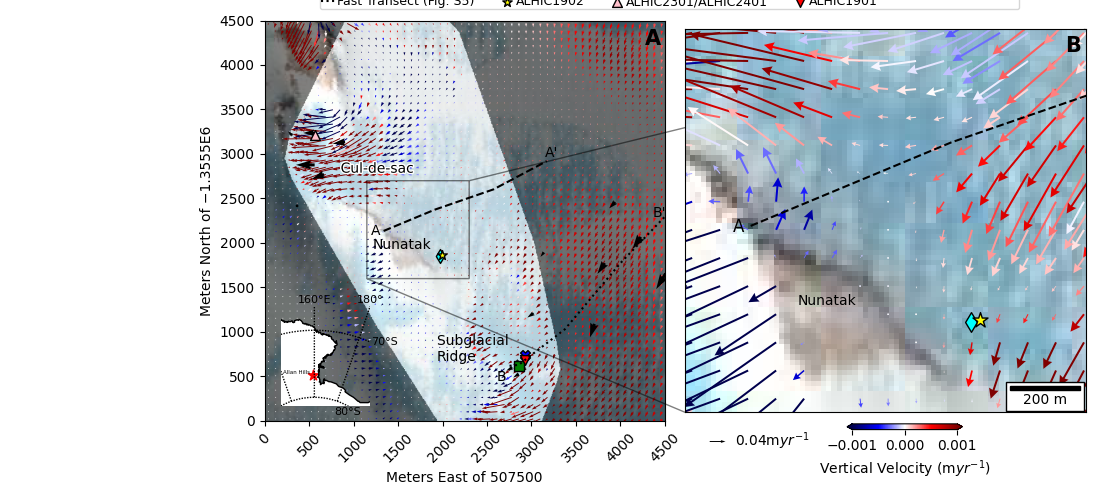

In [18]:
m_above_bed = 10

coords = []
u_vel = []
v_vel = []
w_vel = []

for x_bed_coord, y_bed_coord, z_bed_coord in bed_of_mesh_coords_arr:
    try:
        velocity_ms = flow.at((x_bed_coord, y_bed_coord, z_bed_coord+m_above_bed))
        u_vel.append(velocity_ms[0][0]*enhancement_factor)
        v_vel.append(velocity_ms[0][1]*enhancement_factor)
        w_vel.append(velocity_ms[0][2]*enhancement_factor)
        coords.append((x_bed_coord, y_bed_coord, z_bed_coord))
    
    except Exception as e: 
        # print(e)
        continue

fig, axes = plt.subplots(figsize=[11,5])


vel_cross = np.array([u_vel, v_vel, w_vel]).T
vel_cross_coords = np.asarray(coords)

norm_model = mcolors.Normalize(vmin=-0.001, vmax=0.001)
cmap = plt.cm.seismic
colors_model = cmap(norm_model(vel_cross[:,2]*spy))



show(image_data,ax=axes,transform=src1.transform)




Q = axes.quiver(vel_cross_coords[:,0], vel_cross_coords[:,1], vel_cross[:,0]*spy, vel_cross[:,1]*spy, 
                angles='xy', scale_units='xy', scale=None, color=colors_model)

axes.set_xlim([vel_cross_coords[:,0].min()-100, vel_cross_coords[:,0].max()+100])
axes.set_ylim([vel_cross_coords[:,1].min()-100, vel_cross_coords[:,1].max()+100])

# Colorbar
# sm = cm.ScalarMappable(cmap=cmap, norm=norm_model)
# sm.set_array([])  # Needed only to satisfy colorbar creation
# cbar = plt.colorbar(sm, ax=axes, fraction=0.026, pad=0.04)
# cbar.set_label('Vertical Velocity (m/yr)')

# import matplotlib.ticker as ticker
# cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))

### Colorbar for Model ###
cbar_ax = axes.inset_axes([.4, .04, 1, .3], xticks=[], yticks=[], facecolor="None") # Example: left, bottom, width, height
sm = cm.ScalarMappable(cmap=cmap, norm=norm_model)
cbar = plt.colorbar(sm, ax=cbar_ax, fraction=0.05, pad=0.04, location='bottom', extend='both')
cbar_ax.spines['left'].set_edgecolor('none')
cbar_ax.spines['right'].set_edgecolor('none')
cbar_ax.spines['top'].set_edgecolor('none')
cbar_ax.spines['bottom'].set_edgecolor('none')
cbar.set_label('Vertical Velocity (m'+r"$yr^{-1}$"+")")
import matplotlib.ticker as ticker
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))


# quiverkey_scale = .1
# quiverkey_scale_str = str(quiverkey_scale)




# qk = axes.quiverkey(Q, 1.06, 0.45, quiverkey_scale, quiverkey_scale_str+r'$\frac{m}{yr}$', labelpos='E', coordinates='axes', color='black')

colors_gps = cmap(norm_model(gps_velocities['w']))
axes.quiver(gps_velocities['x'], gps_velocities['y'], 
                gps_velocities['u'], gps_velocities['v'], 
                angles='xy', scale_units='xy', scale=None,
                #color=colors_gps
                )

show(good_dem_filter,ax=axes,transform=src_good_dem.transform,cmap='gray', alpha=0.5)

### Transect Plots ###

axes.plot(upsampled_flowline_xs[:26], upsampled_flowline_ys[:26], ls='--', label = 'Slow Transect (Fig. 2)', c='black')
axes.plot(flowline_surf2['E'][25:46], flowline_surf2['N'][25:46], ls='dotted', label = 'Fast Transect (Fig. S5)', c='black')


axes.annotate('A',xy=(.265,.465),xytext=(.265,.465), xycoords='axes fraction')
axes.annotate('A\'',xy=(.70,.66),xytext=(.70,.66), xycoords='axes fraction')

axes.annotate('B',xy=(.58,.10),xytext=(.58,.10), xycoords='axes fraction')
axes.annotate('B\'',xy=(.97,.51),xytext=(.97,.51), xycoords='axes fraction')


## Plotting and annotating boreholes ##



axes.scatter(transformed_x[5],transformed_y[5], marker='d',ec='black', fc="cyan", s=50, label=borehole_locations.iloc()[5]['Core'])
# axes.annotate(borehole_locations.iloc()[5]['Core'], (transformed_x[5]+60,transformed_y[5]-150), weight='bold')

axes.scatter(transformed_x[1],transformed_y[1], marker='*',ec='black', fc="yellow", s=50, label=borehole_locations.iloc()[1]['Core'])
# axes.annotate(borehole_locations.iloc()[1]['Core'], (transformed_x[1]+20,transformed_y[1]+20), weight='bold');

# axes.scatter(transformed_x[2],transformed_y[2], marker='v',ec='blue', fc="None", label=borehole_locations.iloc()[2]['Core'])
# axes.annotate(borehole_locations.iloc()[2]['Core'], (transformed_x[2]+20,transformed_y[2]+20), weight='bold')

axes.scatter(transformed_x[3],transformed_y[3], marker='s',ec='black', fc="green", s=50, label=borehole_locations.iloc()[3]['Core'])
# axes.annotate(borehole_locations.iloc()[3]['Core'], (transformed_x[3]+40,transformed_y[3]-150), weight='bold')

axes.scatter(transformed_x[4],transformed_y[4], marker='^',ec='black', fc="pink", s=50, label=borehole_locations.iloc()[4]['Core']+"/"+borehole_locations.iloc()[6]['Core'])
# axes.annotate(borehole_locations.iloc()[4]['Core'], (transformed_x[4]+40,transformed_y[4]+120), weight='bold')


#axes.scatter(transformed_x[6],transformed_y[6], marker='D',ec='orange', fc="orange", label=borehole_locations.iloc()[6]['Core'])
# axes.annotate(borehole_locations.iloc()[6]['Core'], (transformed_x[6]+60,transformed_y[6]-50), weight='bold')

axes.scatter(transformed_x[7],transformed_y[7], marker='X',ec='black', fc="blue", s=50,label=borehole_locations.iloc()[7]['Core'])
# axes.annotate(borehole_locations.iloc()[7]['Core'], (transformed_x[7]-920,transformed_y[7]+20))

axes.scatter(transformed_x[0],transformed_y[0], marker='v',ec='black', fc="red", s=50, label=borehole_locations.iloc()[0]['Core'])
# axes.annotate(borehole_locations.iloc()[0]['Core'], (transformed_x[0]+70,transformed_y[0]-50), weight='bold')

#axes.scatter(transformed_x[8],transformed_y[8], marker='p',ec='pink', fc="pink", label=borehole_locations.iloc()[8]['Core'])
# axes.annotate(borehole_locations.iloc()[8]['Core'], (transformed_x[8]+20,transformed_y[8]-200))

# transformed_x2501, transformed_y2501 = transformer.transform(159.34827, -76.73339)
# axes.scatter(transformed_x2501,transformed_y2501, marker='o',ec='red', fc="None", label='ALHIC2501')
# axes.annotate('ALHIC2501', (transformed_x2501+50,transformed_y2501-20))

axes.scatter([], [], marker=r'$\longrightarrow$', color="black", s=120, label="GNSS velocities")



fig.legend(ncols=5, bbox_to_anchor=(1.9,1.13), fontsize=9, 
            borderpad=0.1, handletextpad=0.1, handlelength=1.2,
            bbox_transform=axes.transAxes)


axes.set_xlim([507500, 512000])
axes.set_ylim([-1.3555e6, -1.351e6])

axes.xaxis.set_tick_params(rotation=45)


# axes.set_title("Velocity "+str(m_above_bed)+' m Above Bed')
axins = axes.inset_axes(
    [1.05, 0, 1, 1],
    xticks=[], 
    yticks=[]
    )
show(image_data,ax=axins,transform=src1.transform)
Q_in = axins.quiver(vel_cross_coords[:,0], vel_cross_coords[:,1], vel_cross[:,0]*spy, vel_cross[:,1]*spy, 
                angles='xy', scale_units='xy', scale=2e-5, 
                width = 0.005,
                color=colors_model, 
                headwidth = 5,
                headlength = 5,
                minshaft = 2)


axins.scatter(transformed_x[5],transformed_y[5], marker='d',ec='black', fc="cyan",s=100)
# axins.annotate(borehole_locations.iloc()[5]['Core'], (transformed_x[5]-250,transformed_y[5]-50), weight='bold')

axins.scatter(transformed_x[1],transformed_y[1], marker='*',ec='black', fc="yellow",s=130)
# axins.annotate(borehole_locations.iloc()[1]['Core'], (transformed_x[1]+10,transformed_y[1]+30), weight='bold')


axins.set_xlim([508650, 509800])
axins.set_ylim([-1.3539e6, -1.3528e6])
axes.indicate_inset_zoom(axins, edgecolor="black")


quiverkey_scale = .04
quiverkey_scale_str = str(quiverkey_scale)

qk = axes.quiverkey(Q, 1.15, -0.05, quiverkey_scale, quiverkey_scale_str+"m"+r'$yr^{-1}$', labelpos='E', coordinates='axes', color='black')


axins.plot(upsampled_flowline_xs, upsampled_flowline_ys, ls='--', c='black')

axes.set_xlabel('Meters East of '+axes.get_xticklabels()[0].get_text())
axes.set_ylabel('Meters North of '+axes.get_yticklabels()[0].get_text()+'E6')


x_tick_labels = [int(float(item.get_text()) -  float(axes.get_xticklabels()[0].get_text())) for item in axes.get_xticklabels()]
axes.set_xticklabels(x_tick_labels)

y_tick_labels = [int(float(item.get_text().replace('−','-'))*1e6 -  float(axes.get_yticklabels()[0].get_text().replace('−','-'))*1e6) for item in axes.get_yticklabels()]
axes.set_yticklabels(y_tick_labels)

ax_basemap = inset_axes(axes, "25%", "25%", loc="lower left",  bbox_to_anchor=(0.01,0.02,1,1), bbox_transform=axes.transAxes)
ax_basemap.patch.set_alpha(0)
m = Basemap(projection='stere',resolution='l', lat_0 = (-80+-65)/2, lon_0 = (180+140)/2,
            llcrnrlon=130,urcrnrlon=180,llcrnrlat=-80,urcrnrlat=-65,ax=ax_basemap)
m.drawcoastlines()
m.fillcontinents(color='white',lake_color='aqua', zorder=0)

parallels = np.arange(-90,-60,10)
meridians = np.arange(120, 200,20)
m.drawparallels(parallels, labels=[False,True,True,True], fontsize=8)
m.drawmeridians(meridians,labels=[False,False,True,False], fontsize=8)
ax_basemap.axis('off')
ah_x_loc, ah_y_loc = m(borehole_locations['E'][0],borehole_locations['S'][0])
ax_basemap.scatter(ah_x_loc, ah_y_loc, s=60,marker='*', c='red')
ax_basemap.annotate('Allan Hills',(ah_x_loc-5e5, ah_y_loc+2e4), fontsize=4)

scalebar = AnchoredSizeBar(axins.transData,
                           200, '200 m', 'lower right', 
                           pad=0.3,
                           color='black',
                           frameon=True,
                           size_vertical=10)

axins.add_artist(scalebar)


axes.annotate('Nunatak', xy=(.36,.42),xytext=(.27,.43), xycoords='axes fraction')
axins.annotate('Nunatak', xy=(.30,.30),xytext=(.28,.28), xycoords='axes fraction', )


axes.annotate('Cul-de-sac', xy=(.23,.65),xytext=(.19,.62), xycoords='axes fraction',path_effects=[pe.withStroke(linewidth=2, foreground="white")])

axes.annotate('Subglacial \nRidge', xy=(.36,.42),xytext=(.43,.15), xycoords='axes fraction')

axes.annotate("A", xy=(.95,.94),xycoords='axes fraction', fontsize=15, weight='bold')
axins.annotate("B", xy=(.95,.94),xycoords='axes fraction', fontsize=15, weight='bold')

axins.annotate('A', xy=(.15,.60),xytext=(.12,.47), xycoords='axes fraction', fontsize=12)

plt.tight_layout()
plt.savefig('Figures/fig1_updated_80m_subplot_v3_diss_wEnhance.eps', dpi=600, bbox_inches='tight', format='eps', transparent=True)
plt.savefig('Figures/fig1_updated_80m_subplot_v3_diss_wEnhance.pdf', dpi=600, bbox_inches='tight', format='pdf', transparent=False)
plt.savefig('Figures/fig1_updated_80m_subplot_v3_diss_wEnhance.png', dpi=600, bbox_inches='tight', format='png', transparent=False)

# Calculate depth-averaged velocities

In [86]:
core_age_all = []
speed_all = []
core_names_all = []

z_vals = mesh_fine.coordinates.dat.data_ro[:,2]
depth_values = np.arange(z_vals.min(), z_vals.max(), 1)

speed_dict = {}

for x_bore,y_bore,age, core_name in zip(transformed_x, transformed_y, borehole_locations['oldest ice'], borehole_locations['Core']):
    if core_name == 'ALHIC1903':
        continue
    sampled_speed_prof = []
    z_depth_prof = []
    u_prof = []
    v_prof = []
    w_prof = []

    for z_bore in depth_values:
        try:
            vels = flow.at((x_bore, y_bore, z_bore))
        except:
            continue
        
        u_prof.append(vels[0][0]*enhancement_factor)
        v_prof.append(vels[0][1]*enhancement_factor)
        w_prof.append(vels[0][2]*enhancement_factor)

        sampled_speed = np.sqrt(vels[0][0]**2 + vels[0][1]**2 + vels[0][2]**2)*spy*1000
        sampled_speed_prof.append(sampled_speed)
        z_depth_prof.append(z_bore)

    z_depth_prof = np.array(z_depth_prof)
    sampled_speed_prof = np.array(sampled_speed_prof)

    speed_all.append(sampled_speed_prof)

    core_age_all.append(float(age/1e6))
    
    core_names_all.append(core_name)

    speed_dict[core_name] = [[np.array(u_prof), np.array(v_prof), np.array(w_prof)],z_depth_prof]


In [89]:
for i in speed_dict:
    speed_prof = np.sqrt(np.sum((np.array(speed_dict[i][0][:]).T*spy*1000)**2, axis=1))
    vert_prof = speed_dict[i][0][2]*spy*1000
    print(i+': '+str(np.mean(speed_prof[:20])))
    # print(i+': '+str(np.mean(speed_prof[:])))

ALHIC1901: 11.877349419365192
ALHIC1902: 0.5387148599333654
ALHIC2201: 14.432892893992772
ALHIC2301: 45.787805636352736
ALHIC2302: 0.37610971349180045
ALHIC2401: 49.218449795402094
ALHIC1502: 9.467948097835823
PICO2201: 44.763929845495845


In [57]:
alhic1902_prof = np.sqrt(np.sum((np.array(speed_dict['ALHIC1902'][0]).T*spy*1000)**2, axis=1))
alhic2302_prof = np.sqrt(np.sum((np.array(speed_dict['ALHIC2302'][0]).T*spy*1000)**2, axis=1))
alhic1901_prof = np.sqrt(np.sum((np.array(speed_dict['ALHIC1901'][0]).T*spy*1000)**2, axis=1))

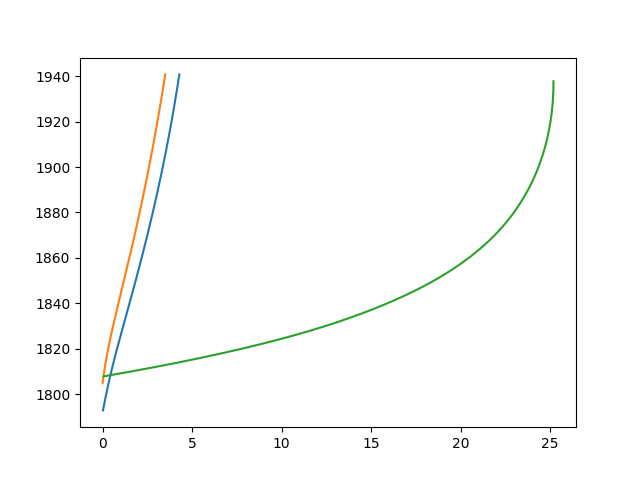

In [58]:
fig,ax = plt.subplots()

ax.plot(alhic1902_prof,speed_dict['ALHIC1902'][1])
ax.plot(alhic2302_prof,speed_dict['ALHIC2302'][1])
ax.plot(alhic1901_prof,speed_dict['ALHIC1901'][1])

In [63]:
print(np.mean(alhic1902_prof[:20]))
print(np.mean(alhic2302_prof[:20]))

0.27345931976312965
0.19091863629025402


In [56]:
speed_dict['ALHIC1902'][1]

array([1792.7978852, 1793.7978852, 1794.7978852, 1795.7978852,
       1796.7978852, 1797.7978852, 1798.7978852, 1799.7978852,
       1800.7978852, 1801.7978852, 1802.7978852, 1803.7978852,
       1804.7978852, 1805.7978852, 1806.7978852, 1807.7978852,
       1808.7978852, 1809.7978852, 1810.7978852, 1811.7978852,
       1812.7978852, 1813.7978852, 1814.7978852, 1815.7978852,
       1816.7978852, 1817.7978852, 1818.7978852, 1819.7978852,
       1820.7978852, 1821.7978852, 1822.7978852, 1823.7978852,
       1824.7978852, 1825.7978852, 1826.7978852, 1827.7978852,
       1828.7978852, 1829.7978852, 1830.7978852, 1831.7978852,
       1832.7978852, 1833.7978852, 1834.7978852, 1835.7978852,
       1836.7978852, 1837.7978852, 1838.7978852, 1839.7978852,
       1840.7978852, 1841.7978852, 1842.7978852, 1843.7978852,
       1844.7978852, 1845.7978852, 1846.7978852, 1847.7978852,
       1848.7978852, 1849.7978852, 1850.7978852, 1851.7978852,
       1852.7978852, 1853.7978852, 1854.7978852, 1855.7

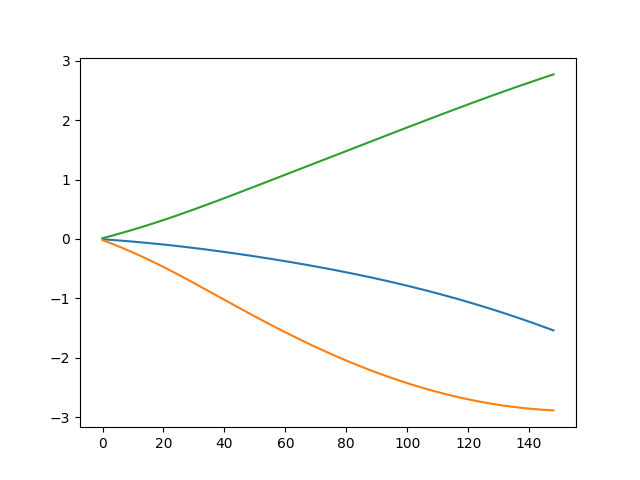

In [ ]:
fig,ax=plt.subplots()
ax.plot(np.sqrt(np.array(speed_dict['ALHIC1902'][0]).T*spy*1000)

In [42]:
np.array(speed_dict['ALHIC1902'][0])*spy*1000

array([[-0.00370964, -0.00748706, -0.01132662, -0.01523024, -0.01919983,
        -0.02323731, -0.02734457, -0.03152355, -0.03577614, -0.04010426,
        -0.04450983, -0.04899475, -0.05356094, -0.05821032, -0.06294478,
        -0.06776625, -0.07267663, -0.07767785, -0.08277181, -0.08796042,
        -0.09324559, -0.09862925, -0.1041133 , -0.10969965, -0.11539021,
        -0.12118691, -0.12709164, -0.13310633, -0.13923288, -0.14546542,
        -0.15172703, -0.15806495, -0.16447903, -0.17096911, -0.17753504,
        -0.18417665, -0.19089378, -0.19768629, -0.20455401, -0.21149679,
        -0.21851447, -0.22560689, -0.23277389, -0.24001531, -0.24733101,
        -0.25472081, -0.26218457, -0.26972212, -0.27733332, -0.28501799,
        -0.29277599, -0.30060715, -0.30851132, -0.31648834, -0.32453806,
        -0.33266031, -0.34085494, -0.34912179, -0.3574607 , -0.36587465,
        -0.37437238, -0.38294395, -0.39159058, -0.40031346, -0.40911378,
        -0.41799276, -0.42695159, -0.43599147, -0.4

In [69]:
for name in speed_dict:
    vel_list = speed_dict[name][0]
    hor_avg = np.mean(np.sqrt(vel_list[0]**2 + vel_list[1]**2))*spy*1000
    vert_avg = np.mean(vel_list[2])*spy*1000*enhancement_factor
    print(name+' horizontal velocity = '+str(hor_avg)+ ' and vertical velocity = '+ str(vert_avg))


ALHIC1901 horizontal velocity = 36.3906547405088 and vertical velocity = 21.66504092386869
ALHIC1902 horizontal velocity = 3.625640215980685 and vertical velocity = 5.307247456475483
ALHIC2201 horizontal velocity = 31.06466591366596 and vertical velocity = 18.825862467790017
ALHIC2301 horizontal velocity = 129.0448804982283 and vertical velocity = 95.74193886384123
ALHIC2302 horizontal velocity = 2.8367573169877085 and vertical velocity = 4.225860053086596
ALHIC2401 horizontal velocity = 134.83844282322482 and vertical velocity = 97.72474243785862
ALHIC1502 horizontal velocity = 37.958523741417956 and vertical velocity = 21.467136158772572
PICO2201 horizontal velocity = 127.02718393425894 and vertical velocity = 94.80578593567456


In [16]:
gps_velocities['x']

0     508405.218009
1     516925.243800
2     507813.394757
3     514805.118422
4     512933.076191
5     513497.113706
6     513269.870190
7     514023.075022
8     510523.607419
9     512569.068527
10    514723.857508
11    514992.998257
12    510640.403889
13    511441.420272
14    514481.327304
15    512987.053867
16    513800.724480
17    515517.830419
18    512193.004711
19    510286.178053
20    515563.637685
21    514514.174479
22    514647.306097
23    514403.726389
24    513029.282824
25    511324.096309
26    512146.213144
27    514562.105757
28    510429.555020
29    510358.182016
30    512006.777987
31    511728.527356
32    514932.790977
33    511206.723017
34    513449.070291
35    510357.220839
36    515465.221813
37    515129.079858
38    513712.863700
39    515412.127229
40    513082.190268
41    514252.734690
42    514586.141380
43    507865.874000
44    508167.788951
45    508058.109053
46    508063.262572
47    510356.836715
48    513821.464990
49    514835.403798


In [ ]:
vel_profiles = {}

hor_diffs = []
ver_diffs = []

u_GPS_vel = []
v_GPS_vel = []

u_model = []
v_model = []

for x_coord, y_coord, i in zip(gps_velocities['x'].values, gps_velocities['y'].values, gps_velocities.iloc()):
    
    vel_prof = []
    vel_prof_coords = []

    site_name = i['Name']
    site_gps_hor_vel = np.sqrt(i['u']**2 + i['v']**2)
    site_gps_ver_vel = i['w']

    hor_prof = []
    ver_profile = []

    for z_coord in depth_values:
        try:
            velocity = flow.at(x_coord, y_coord, z_coord)[0]*spy
            vel_prof.append(velocity)
            hor_prof.append(np.sqrt(velocity[0]**2 + velocity[1]**2))
            ver_profile.append(velocity[2])
            vel_prof_coords.append([x_coord, y_coord, z_coord])
        except:
            continue
    try:
        vel_profiles[site_name] = [np.array(vel_prof_coords)[:,-1],hor_prof,ver_profile]

        hor_diff = hor_prof[-1] - site_gps_hor_vel
        hor_diffs.append(hor_diff)
        print(site_gps_hor_vel)

        ver_diff = ver_profile[-1] - site_gps_ver_vel
        ver_diffs.append(ver_diff)

        u_GPS_vel.append(i['u'])
        v_GPS_vel.append(i['v'])

        u_model.append(vel_prof[-1][0])
        v_model.append(vel_prof[-1][1])


    except:
        continue

In [28]:
print("mean horizontal surface vel:  "+str(np.mean(hor_diffs)*1000))
print("mean vertical surface vel:  "+str(np.mean(ver_diffs)*1000))

mean horizontal surface vel:  -64.76706593470406
mean vertical surface vel:  -14.84110157665343


In [40]:
np.mean(np.sqrt(np.array(u_GPS_vel)**2+np.array(v_GPS_vel)**2))*1000

np.float64(116.05490821949837)

In [32]:
theta_GPS = np.arctan2(v_GPS_vel, u_GPS_vel) * (180/np.pi)
theta_model = np.arctan2(v_model, u_model) * (180/np.pi)

theta_GPS_fix = []
theta_model_fix = []
for th_GPS, th_model in zip(theta_GPS, theta_model):
    if th_GPS < 0:
        new_GPS = th_GPS+360
        theta_GPS_fix.append(new_GPS)
    else:
        theta_GPS_fix.append(th_GPS)
    if th_model < 0:
        new_model = th_model+360
        theta_model_fix.append(new_model)
    else:
        theta_model_fix.append(th_model)

theta_GPS_fix = np.array(theta_GPS_fix)
theta_model_fix = np.array(theta_model_fix)

In [33]:
np.average(np.abs(theta_GPS_fix - theta_model_fix))

np.float64(11.149961844463576)